# Кластеризация по Сегментации пациентов

## Загрузка данных

### Подключение необходимых библиотек и функций

In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering, SpectralClustering
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder , OneHotEncoder, OrdinalEncoder, StandardScaler, RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans , DBSCAN , AgglomerativeClustering
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram


import warnings
warnings.filterwarnings('ignore')

## Обзор датасета

In [80]:
df = pd.read_csv("patient_segmentation_dataset.csv")

In [81]:
df

,PatientID,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
0,P10000,64,Male,GA,Unknown,151,115,50.4,Private,Arthritis,3,7,2995.0,2025-07-18,186,0
1,P10001,59,Male,OH,Unknown,189,68,19.0,Medicare,Depression,1,8,1209.0,2025-12-12,39,0
2,P10002,58,Female,PA,Unknown,156,91,37.4,Private,Asthma,1,4,999.0,2025-09-16,126,0
3,P10003,43,Female,GA,Unknown,152,92,39.8,Medicare,Hypertension,1,6,5638.5,2025-04-09,286,1
4,P10004,53,Female,NC,Unknown,167,51,18.3,Medicaid,Asthma,1,4,5796.0,2025-03-07,319,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,P11995,37,Male,IL,Springfield,195,109,28.7,Medicaid,NaN,0,4,4581.0,2025-09-20,122,1
1996,P11996,32,Female,NY,Rochester,151,94,41.2,Private,NaN,0,1,329.0,2025-08-23,150,1
1997,P11997,50,Female,NC,Unknown,149,115,51.8,Private,Anxiety,1,8,4942.5,2025-05-23,242,1
1998,P11998,74,Female,NC,Unknown,165,97,35.6,Medicare,Heart Disease,3,7,4700.0,2025-07-09,195,1


Расшифровка каждого атрибута
- PatientID - Индетификатор пациента
- Age - Возраст пациента
- Gender - Пол пациента
- State	- Штат
- City - Город
- Height_cm - Рост пациента (в см)
- Weight_kg - Вес пациента (в кг)
- BMI - Индекс массы тела
- Insurance_Type - Тип мед страхования
- Primary_Condition - Основное заболевание
- Num_Chronic_Conditions - Число хронических условий
- Annual_Visits	- Ежегодные визиты
- Avg_Billing_Amount - Среднее количество выставляемых счетов
- Last_Visit_Date - Последняя дата визита
- Days_Since_Last_Visit - Количество дней после последнего визита
- Preventive_Care_Flag - Предупреждающий флажок

In [82]:
df_original = df.copy()

## Разведочный анализ данных (РАД/EDA)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PatientID               2000 non-null   object 
 1   Age                     2000 non-null   int64  
 2   Gender                  2000 non-null   object 
 3   State                   2000 non-null   object 
 4   City                    2000 non-null   object 
 5   Height_cm               2000 non-null   int64  
 6   Weight_kg               2000 non-null   int64  
 7   BMI                     2000 non-null   float64
 8   Insurance_Type          2000 non-null   object 
 9   Primary_Condition       1505 non-null   object 
 10  Num_Chronic_Conditions  2000 non-null   int64  
 11  Annual_Visits           2000 non-null   int64  
 12  Avg_Billing_Amount      2000 non-null   float64
 13  Last_Visit_Date         2000 non-null   object 
 14  Days_Since_Last_Visit   2000 non-null   

#### В данном наборе данных 15 столбцов и 2000 строчек 
#### Есть значения NaN (пропущенные) в столбце Primary_Condition (Основное заболевание)

In [84]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2000.0,50.69550,15.444450,18.0,40.0,51.00,63.250,87.0
Height_cm,2000.0,167.90750,12.684494,145.0,158.0,168.00,177.000,195.0
Weight_kg,2000.0,85.14350,20.385428,50.0,67.0,86.00,103.000,120.0
BMI,2000.0,30.74065,8.839952,13.4,23.8,30.10,37.025,57.1
Num_Chronic_Conditions,2000.0,1.08000,0.890504,0.0,1.0,1.00,1.000,3.0
Annual_Visits,2000.0,5.46650,3.485965,1.0,3.0,4.00,8.000,12.0
Avg_Billing_Amount,2000.0,4000.27050,2463.239215,207.0,2061.0,3707.25,5650.875,12467.5
Days_Since_Last_Visit,2000.0,180.08500,104.688484,1.0,90.0,183.00,268.000,365.0
Preventive_Care_Flag,2000.0,0.46400,0.498827,0.0,0.0,0.00,1.000,1.0


In [85]:
df.shape

(2000, 16)

In [86]:
df.dtypes

PatientID                  object
Age                         int64
Gender                     object
State                      object
City                       object
Height_cm                   int64
Weight_kg                   int64
BMI                       float64
Insurance_Type             object
Primary_Condition          object
Num_Chronic_Conditions      int64
Annual_Visits               int64
Avg_Billing_Amount        float64
Last_Visit_Date            object
Days_Since_Last_Visit       int64
Preventive_Care_Flag        int64
dtype: object

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PatientID               2000 non-null   object 
 1   Age                     2000 non-null   int64  
 2   Gender                  2000 non-null   object 
 3   State                   2000 non-null   object 
 4   City                    2000 non-null   object 
 5   Height_cm               2000 non-null   int64  
 6   Weight_kg               2000 non-null   int64  
 7   BMI                     2000 non-null   float64
 8   Insurance_Type          2000 non-null   object 
 9   Primary_Condition       1505 non-null   object 
 10  Num_Chronic_Conditions  2000 non-null   int64  
 11  Annual_Visits           2000 non-null   int64  
 12  Avg_Billing_Amount      2000 non-null   float64
 13  Last_Visit_Date         2000 non-null   object 
 14  Days_Since_Last_Visit   2000 non-null   

In [88]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'State', 'City', 'Height_cm', 'Weight_kg',
       'BMI', 'Insurance_Type', 'Primary_Condition', 'Num_Chronic_Conditions',
       'Annual_Visits', 'Avg_Billing_Amount', 'Last_Visit_Date',
       'Days_Since_Last_Visit', 'Preventive_Care_Flag'],
      dtype='object')

In [89]:
for col in df.columns:
    print('Кол-во пропусков в колонке %s = %d' % (col, df[col].isna().sum()))

Кол-во пропусков в колонке PatientID = 0
Кол-во пропусков в колонке Age = 0
Кол-во пропусков в колонке Gender = 0
Кол-во пропусков в колонке State = 0
Кол-во пропусков в колонке City = 0
Кол-во пропусков в колонке Height_cm = 0
Кол-во пропусков в колонке Weight_kg = 0
Кол-во пропусков в колонке BMI = 0
Кол-во пропусков в колонке Insurance_Type = 0
Кол-во пропусков в колонке Primary_Condition = 495
Кол-во пропусков в колонке Num_Chronic_Conditions = 0
Кол-во пропусков в колонке Annual_Visits = 0
Кол-во пропусков в колонке Avg_Billing_Amount = 0
Кол-во пропусков в колонке Last_Visit_Date = 0
Кол-во пропусков в колонке Days_Since_Last_Visit = 0
Кол-во пропусков в колонке Preventive_Care_Flag = 0


In [90]:
df.isnull().sum()

PatientID                   0
Age                         0
Gender                      0
State                       0
City                        0
Height_cm                   0
Weight_kg                   0
BMI                         0
Insurance_Type              0
Primary_Condition         495
Num_Chronic_Conditions      0
Annual_Visits               0
Avg_Billing_Amount          0
Last_Visit_Date             0
Days_Since_Last_Visit       0
Preventive_Care_Flag        0
dtype: int64

##### В столбце Primary_Condition (Основное заболевание) есть пропуски в количестве 495

##### Заполняем значениями первой строки

In [91]:
df['Primary_Condition']=df['Primary_Condition'].fillna(df['Primary_Condition'].mode()[0])

In [92]:
df

,PatientID,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
0,P10000,64,Male,GA,Unknown,151,115,50.4,Private,Arthritis,3,7,2995.0,2025-07-18,186,0
1,P10001,59,Male,OH,Unknown,189,68,19.0,Medicare,Depression,1,8,1209.0,2025-12-12,39,0
2,P10002,58,Female,PA,Unknown,156,91,37.4,Private,Asthma,1,4,999.0,2025-09-16,126,0
3,P10003,43,Female,GA,Unknown,152,92,39.8,Medicare,Hypertension,1,6,5638.5,2025-04-09,286,1
4,P10004,53,Female,NC,Unknown,167,51,18.3,Medicaid,Asthma,1,4,5796.0,2025-03-07,319,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,P11995,37,Male,IL,Springfield,195,109,28.7,Medicaid,Hypertension,0,4,4581.0,2025-09-20,122,1
1996,P11996,32,Female,NY,Rochester,151,94,41.2,Private,Hypertension,0,1,329.0,2025-08-23,150,1
1997,P11997,50,Female,NC,Unknown,149,115,51.8,Private,Anxiety,1,8,4942.5,2025-05-23,242,1
1998,P11998,74,Female,NC,Unknown,165,97,35.6,Medicare,Heart Disease,3,7,4700.0,2025-07-09,195,1


In [93]:
df.isnull().sum()

PatientID                 0
Age                       0
Gender                    0
State                     0
City                      0
Height_cm                 0
Weight_kg                 0
BMI                       0
Insurance_Type            0
Primary_Condition         0
Num_Chronic_Conditions    0
Annual_Visits             0
Avg_Billing_Amount        0
Last_Visit_Date           0
Days_Since_Last_Visit     0
Preventive_Care_Flag      0
dtype: int64

##### Теперь пропущеных значений нет

#### Проверка уникальных значений в целевой переменной

In [94]:
df['Primary_Condition'].nunique()

9

In [95]:
df['Primary_Condition'].unique()

array(['Arthritis', 'Depression', 'Asthma', 'Hypertension', 'Anxiety',
       'Heart Disease', 'Obesity', 'COPD', 'Diabetes'], dtype=object)

In [96]:
df['Primary_Condition'].value_counts(normalize=True)

Primary_Condition
Hypertension     0.3525
Obesity          0.0915
Anxiety          0.0875
Arthritis        0.0815
Asthma           0.0800
Depression       0.0800
Diabetes         0.0790
Heart Disease    0.0750
COPD             0.0730
Name: proportion, dtype: float64

##### Наиболее частое заболевание - гипертрония

#### Распределение возраста и пола пациентов

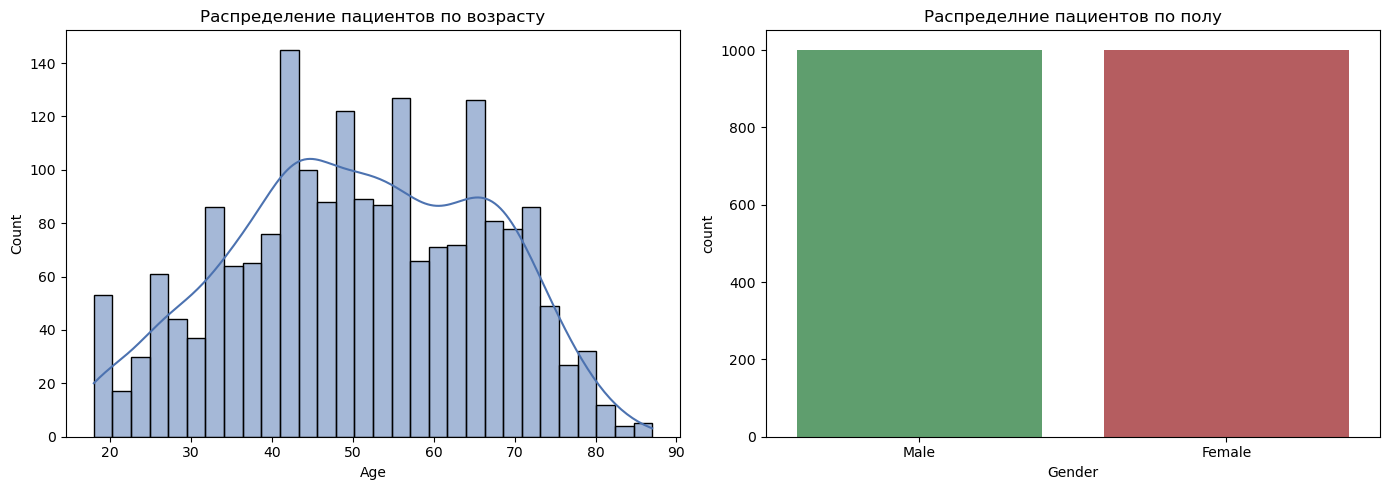

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df,
    x="Age",
    bins=30,
    kde=True,
    ax=axes[0],
    color="#4C72B0")

axes[0].set_title("Распределение пациентов по возрасту")
sns.countplot(
    data=df,
    x="Gender",
    ax=axes[1],
    palette=["#55A868", "#C44E52"])

axes[1].set_title("Распределние пациентов по полу")

plt.tight_layout()
plt.show()

### Распределение индекса массы тела (BMI) и количество хронических заболеваний

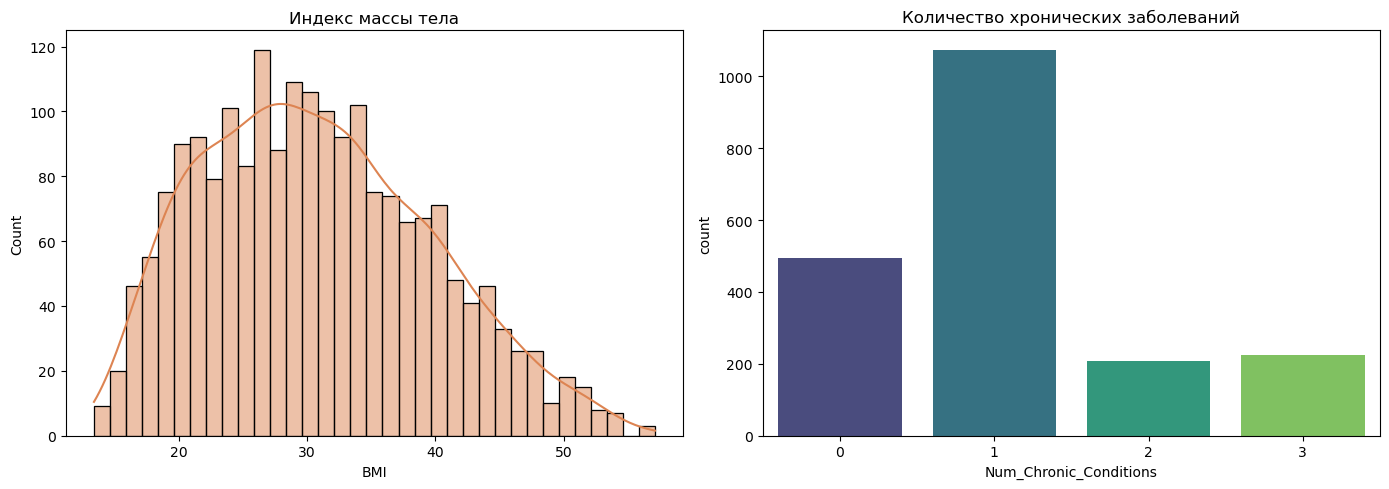

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df["BMI"],
    bins=35,
    kde=True,
    ax=axes[0],
    color="#DD8452")

axes[0].set_title("Индекс массы тела")

sns.countplot(
    data=df,
    x="Num_Chronic_Conditions",
    ax=axes[1],
    palette="viridis")

axes[1].set_title("Количество хронических заболеваний")

plt.tight_layout()
plt.show()

### Матрица корреляций

In [99]:
numeric_cols = ['BMI', 'Num_Chronic_Conditions', 'Age', 'Annual_Visits', 'Avg_Billing_Amount']
corr_matrix = df[numeric_cols].corr()

## Связь индекса массы тела и количеством хронических заболеваний

### Корреляция индекса массы тела и количеством хронических заболеваний

In [100]:
correlation = df['BMI'].corr(df['Num_Chronic_Conditions'])
print(f"Корреляция BMI и хронических заболеваний: {correlation:.3f}")

Корреляция BMI и хронических заболеваний: 0.032


### Среднее количество заболеваний по категориям BMI

In [101]:
bmi_groups = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 35, 40, 100],
                     labels=['Дефицит', 'Норма', 'Избыток', 
                             'Ожирение I', 'Ожирение II', 'Ожирение III'])


In [102]:
chronic_by_bmi = df.groupby(bmi_groups)['Num_Chronic_Conditions'].agg(['mean', 'median', 'count'])
print("\nСреднее количество заболеваний по категориям BMI:")
print(chronic_by_bmi.round(2))


Среднее количество заболеваний по категориям BMI:
              mean  median  count
BMI                              
Дефицит       0.98     1.0    140
Норма         1.07     1.0    455
Избыток       1.08     1.0    404
Ожирение I    1.07     1.0    396
Ожирение II   1.14     1.0    278
Ожирение III  1.10     1.0    327


### Годовые визиты пациентов и дней с момента последнего визита

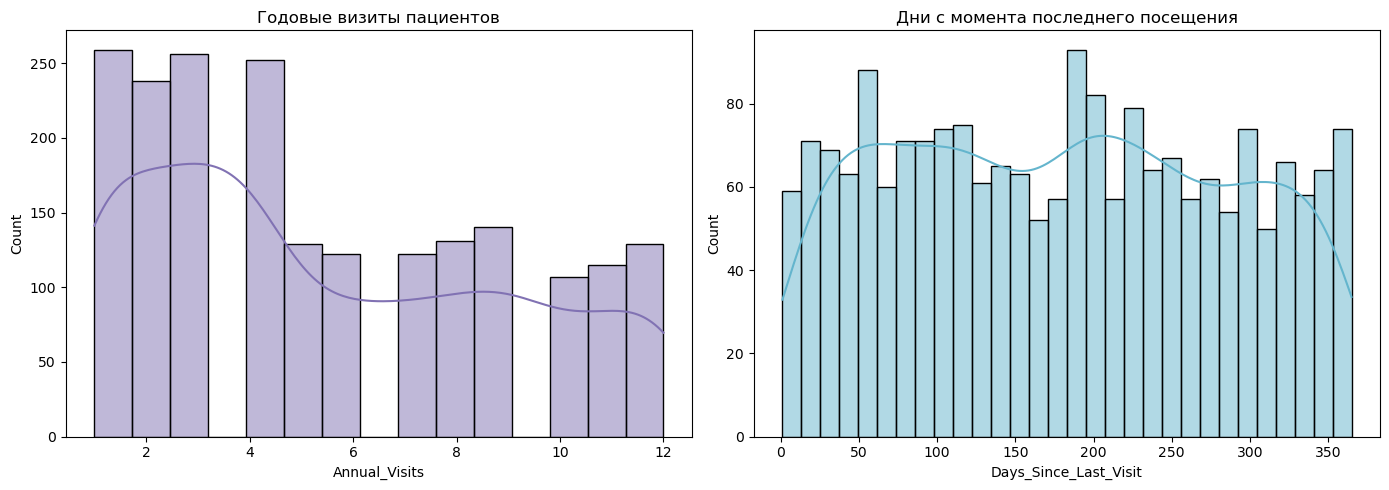

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df["Annual_Visits"],
    bins=15,
    kde=True,
    ax=axes[0],
    color="#8172B3")
axes[0].set_title("Годовые визиты пациентов")
sns.histplot(
    df["Days_Since_Last_Visit"],
    bins=30,
    kde=True,
    ax=axes[1],
    color="#64B5CD")
axes[1].set_title("Дни с момента последнего посещения")

plt.tight_layout()
plt.show()

#### Этап предобработки

In [104]:
clean_DS = df.drop(['PatientID', 'Last_Visit_Date'] , axis =1)
le = LabelEncoder()
clean_DS_Gender = le.fit_transform(clean_DS['Gender'])
clean_DS_Gender = pd.DataFrame(clean_DS_Gender, columns = ['Gender'])

In [105]:
columns = ['State', 'City', 'Insurance_Type', 'Primary_Condition']

In [106]:
df_Numerical = df[['Age', 'BMI' , 'Weight_kg' , 'Height_cm' ,'Preventive_Care_Flag' , 'Days_Since_Last_Visit' , 'Avg_Billing_Amount' , 'Annual_Visits' , 'Num_Chronic_Conditions']]

In [107]:
Numerical_Columns = ['Age', 'BMI' , 'Weight_kg' , 'Height_cm'  , 'Days_Since_Last_Visit' , 'Avg_Billing_Amount' , 'Annual_Visits' , 'Num_Chronic_Conditions']

#### Преобразуем категориальные данные

In [108]:
ohc = OneHotEncoder(sparse_output= False)
clean_DS = ohc.fit_transform(clean_DS[columns])
clean_DS_ohc = pd.DataFrame(clean_DS , columns = ohc.get_feature_names_out())

In [109]:
df = pd.concat([clean_DS_Gender , clean_DS_ohc, df_Numerical], axis = 1)

In [110]:
df

,Gender,State_CA,State_FL,State_GA,State_IL,State_MI,State_NC,State_NY,State_OH,State_PA,...,Primary_Condition_Obesity,Age,BMI,Weight_kg,Height_cm,Preventive_Care_Flag,Days_Since_Last_Visit,Avg_Billing_Amount,Annual_Visits,Num_Chronic_Conditions
0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,64,50.4,115,151,0,186,2995.0,7,3
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,59,19.0,68,189,0,39,1209.0,8,1
2,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,58,37.4,91,156,0,126,999.0,4,1
3,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,43,39.8,92,152,1,286,5638.5,6,1
4,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,53,18.3,51,167,0,319,5796.0,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,37,28.7,109,195,1,122,4581.0,4,0
1996,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,32,41.2,94,151,1,150,329.0,1,0
1997,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,50,51.8,115,149,1,242,4942.5,8,1
1998,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,74,35.6,97,165,1,195,4700.0,7,3


In [111]:
df.describe()[Numerical_Columns].T[['50%', 'mean']]

,50%,mean
Age,51.00,50.69550
BMI,30.10,30.74065
Weight_kg,86.00,85.14350
Height_cm,168.00,167.90750
Days_Since_Last_Visit,183.00,180.08500
Avg_Billing_Amount,3707.25,4000.27050
Annual_Visits,4.00,5.46650
Num_Chronic_Conditions,1.00,1.08000


#### Анализ скошенности

In [112]:
df.select_dtypes('number')[Numerical_Columns].skew()

Age                      -0.105301
BMI                       0.371679
Weight_kg                -0.018466
Height_cm                 0.167846
Days_Since_Last_Visit     0.054967
Avg_Billing_Amount        0.704701
Annual_Visits             0.432123
Num_Chronic_Conditions    0.795998
dtype: float64

#### Метод квантильного ограничения

In [113]:
Upper = df['Avg_Billing_Amount'].quantile(.95)
Lower = df['Avg_Billing_Amount'].quantile(0.05)
df['Avg_Billing_Amount'] = df['Avg_Billing_Amount'].clip(Lower, Upper)

In [114]:
df.select_dtypes('number')[Numerical_Columns].skew()

Age                      -0.105301
BMI                       0.371679
Weight_kg                -0.018466
Height_cm                 0.167846
Days_Since_Last_Visit     0.054967
Avg_Billing_Amount        0.270492
Annual_Visits             0.432123
Num_Chronic_Conditions    0.795998
dtype: float64

#### Преобразуем данные

In [115]:
df.describe()[Numerical_Columns].T[['50%', 'mean']]

,50%,mean
Age,51.00,50.69550
BMI,30.10,30.74065
Weight_kg,86.00,85.14350
Height_cm,168.00,167.90750
Days_Since_Last_Visit,183.00,180.08500
Avg_Billing_Amount,3707.25,3915.08850
Annual_Visits,4.00,5.46650
Num_Chronic_Conditions,1.00,1.08000


#### Кластаризация

In [116]:
scale = MinMaxScaler()
X = scale.fit_transform(df)

#### Метод "локтя"

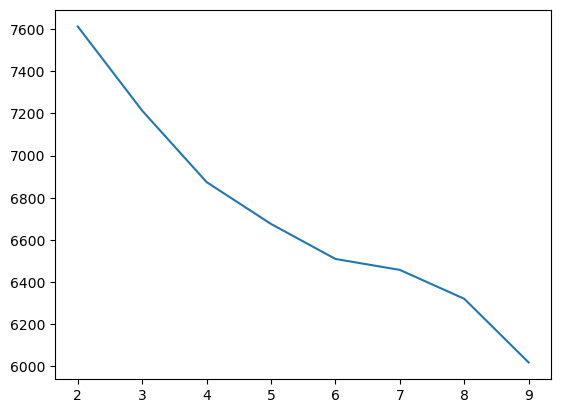

In [117]:
interia = []
for n in range(2 ,10):
  km = KMeans(n_clusters=n)
  y_pred = km.fit_predict(X)
  interia.append(km.inertia_)

plt.plot(range(2,10) , interia)

In [118]:
km = KMeans(n_clusters= 6)
pca = PCA(2)
x_reduced = pca.fit_transform(X)
labels = km.fit_predict(x_reduced)
score = silhouette_score(x_reduced , labels)
print(score)

0.7035223704923251


#### Иерархическая кластеризация

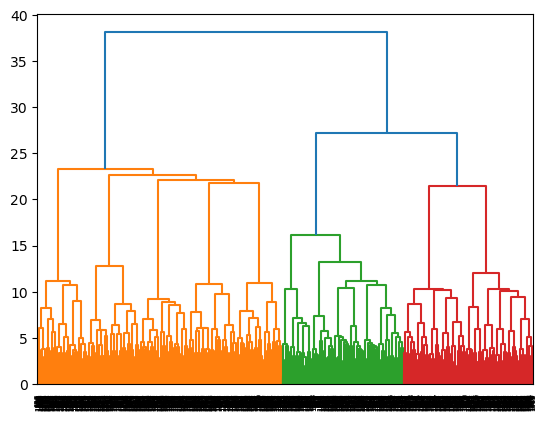

In [119]:
linkage = linkage(X , metric='euclidean' , method='ward')
dendrogram(linkage, orientation='top' );

In [120]:
scores = []
pca = PCA(2)
x_reduced = pca.fit_transform(X)
for n in range(2 ,11):
  aggo = AgglomerativeClustering(n_clusters=n, metric='euclidean' , linkage = 'ward')
  y_pred = aggo.fit_predict(x_reduced)
  scores.append(silhouette_score(x_reduced , y_pred))
print(f"best n_of clusters is {np.argmax(scores)+2}")

best n_of clusters is 6


In [121]:
aggo = AgglomerativeClustering(n_clusters=6, metric='euclidean' , linkage = 'ward')
y_pred = aggo.fit_predict(x_reduced)
silhouette_score(x_reduced , y_pred)

np.float64(0.6907467159334472)

### DBSCAN

In [122]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f"DBSCAN: {n_clusters} кластеров, {n_noise} шумовых точек")

if n_clusters >= 2:
    mask = db_labels != -1
    db_score = silhouette_score(X[mask], db_labels[mask])
    print(f"DBSCAN Silhouette Score: {db_score:.4f}")

DBSCAN: 3 кластеров, 1985 шумовых точек
DBSCAN Silhouette Score: 0.7383


### Визуализация кластеров

In [123]:
df_analysis = df_original.copy() 
df_analysis['Cluster'] = labels

cluster_profile = df_analysis.groupby('Cluster')[['Age', 'BMI', 'Num_Chronic_Conditions', 'Annual_Visits']].mean()

for cluster in range(6):
    print(f"\nКластер {cluster}:")
    print(f"  Средний возраст: {cluster_profile.loc[cluster, 'Age']:.1f}")
    print(f"  Средний ИМТ: {cluster_profile.loc[cluster, 'BMI']:.1f}")
    # Теперь Primary_Condition доступна
    primary_condition = df_analysis[df_analysis['Cluster'] == cluster]['Primary_Condition'].mode()[0]
    print(f"  Основное заболевание: {primary_condition}")


Кластер 0:
  Средний возраст: 50.0
  Средний ИМТ: 30.5
  Основное заболевание: Diabetes

Кластер 1:
  Средний возраст: 50.3
  Средний ИМТ: 30.9
  Основное заболевание: Depression

Кластер 2:
  Средний возраст: 32.5
  Средний ИМТ: 30.5
  Основное заболевание: Hypertension

Кластер 3:
  Средний возраст: 63.1
  Средний ИМТ: 31.5
  Основное заболевание: Obesity

Кластер 4:
  Средний возраст: 62.7
  Средний ИМТ: 30.8
  Основное заболевание: Obesity

Кластер 5:
  Средний возраст: 33.0
  Средний ИМТ: 29.9
  Основное заболевание: Hypertension


### Модели классификации

#### Разделение данных

In [126]:
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, random_state=42)

#### Обучение моделей

In [128]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

In [129]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100)
}

In [130]:
best_score = 0
best_model = None

In [131]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    print(f"\n{name} Accuracy: {score:.4f}")
    print(classification_report(y_test, y_pred))
    
    if score > best_score:
        best_score = score
        best_model = model



LogisticRegression Accuracy: 0.9950
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        83
           1       0.99      1.00      0.99        73
           2       1.00      1.00      1.00        57
           3       1.00      0.99      0.99        72
           4       1.00      0.99      0.99        70
           5       1.00      1.00      1.00        45

    accuracy                           0.99       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      0.99      0.99       400


RandomForest Accuracy: 0.9925
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        83
           1       1.00      0.99      0.99        73
           2       1.00      0.98      0.99        57
           3       0.99      1.00      0.99        72
           4       0.99      1.00      0.99        70
           5       1.00      1.00      1.00        45

    accur

### Лучшая модель

In [132]:
joblib.dump(best_model, 'patient_cluster_model.pkl')
print(f"\nЛучшая модель с accuracy: {best_score:.4f}")


Лучшая модель с accuracy: 0.9950


In [ ]:
#

In [ ]:
df_final = df_original.copy() 
df_final['Cluster'] = labels

In [ ]:
columns_for_dashboard = ['PatientID', 'Age', 'Gender', 'BMI', 'Num_Chronic_Conditions',
                          'Annual_Visits', 'Avg_Billing_Amount', 'Days_Since_Last_Visit',
                          'Primary_Condition', 'Insurance_Type', 'Cluster']
df_dashboard = df_final[columns_for_dashboard]

In [ ]:
df_dashboard.to_csv('patient_segments_data.csv', index=False)
print("Файл 'patient_segments_data.csv' успешно сохранен!")

In [ ]:
cluster_profile = df_dashboard.groupby('Cluster').agg({
    'Age': 'mean',
    'BMI': 'mean',
    'Num_Chronic_Conditions': 'mean',
    'Annual_Visits': 'mean',
    'Avg_Billing_Amount': 'mean',
    'Days_Since_Last_Visit': 'mean'
}).round(1).reset_index()
cluster_profile.to_csv('cluster_profiles.csv', index=False)
print("Файл 'cluster_profiles.csv' успешно сохранен!")